In [1]:
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from scipy.ndimage import binary_closing, gaussian_filter1d
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

import umap

# 1. Setup

In [3]:
BASE_DIR = Path.cwd() / "yang_long_2025_budgie_aac"
OUT_H5 = BASE_DIR / "model_ready_all_parrots" / "all_parrots_audioX_spikesY.h5"

BIRDS = [
    "Bl122_ChronicLeftAAC",
    "Li145_ChronicLeftAAC",
    "Or61_ChronicLeftAAC",
    "Ti81_ChronicLeftAAC",
]

assert OUT_H5.exists(), f"Cannot find {OUT_H5}"

STFT_STEP_SEC = 0.001  # 1 ms bins
RANDOM_STATE = 0

# event detection
MIN_EVENT_MS = 2
CLOSE_GAP_MS = 2
EVENT_ANALYSIS_MS = 3
EVENT_Z_THRESHOLD = 4.0
EVENT_MIN_PIXELS = 50

# audio UMAP / clustering
MAX_EVENTS_PER_BIRD = 400
MIN_AUDIO_WINDOW_MS = 300
FREQ_POOL = 4
AUDIO_PCA_DIM = 30

AUDIO_UMAP_N_NEIGHBORS = 25
AUDIO_UMAP_MIN_DIST = 0.10

DBSCAN_EPS = 0.55
DBSCAN_MIN_SAMPLES = 12

# neural trajectories
TRAJ_PRE_MS = 50
TRAJ_POST_MS = 300
SPIKE_SMOOTH_MS = 20
N_PC = 3

# neural normalization
# False: use smoothed firing rate in Hz
# True:  use unit-wise z-scored smoothed firing rate
NEURAL_UNIT_ZSCORE = False
BASELINE_SUBTRACT = True

NEURAL_SIGNAL_LABEL = (
    "smoothed z-scored firing rate"
    if NEURAL_UNIT_ZSCORE
    else "smoothed firing rate (Hz)"
)

HEATMAP_LABEL = (
    "baseline-subtracted z-rate"
    if NEURAL_UNIT_ZSCORE
    else "baseline-subtracted firing rate (Hz)"
)

MAX_TRAJ_PLOT = 80
MIN_EVENTS_PER_CLUSTER_BIRD = 5

# 2. Data Loading

In [4]:
data = {}

with h5py.File(OUT_H5, "r") as h5:
    for bird in BIRDS:
        data[bird] = {
            "X_audio": h5[bird]["X_audio"][:],       # (time, freq)
            "Y_spikes": h5[bird]["Y_spikes"][:],     # (time, unit)
            "time": h5[bird]["time_audio_sec"][:],
            "freq": h5[bird]["freq_hz"][:],
        }

for bird in BIRDS:
    print("\n" + bird)
    print("audio:", data[bird]["X_audio"].shape)
    print("spikes:", data[bird]["Y_spikes"].shape)
    print("freq:", data[bird]["freq"].shape)


Bl122_ChronicLeftAAC
audio: (299983, 228)
spikes: (299983, 43)
freq: (228,)

Li145_ChronicLeftAAC
audio: (299983, 228)
spikes: (299983, 81)
freq: (228,)

Or61_ChronicLeftAAC
audio: (299983, 228)
spikes: (299983, 47)
freq: (228,)

Ti81_ChronicLeftAAC
audio: (299983, 228)
spikes: (299983, 49)
freq: (228,)


# 3. Figure 1: audio + neural spikes

In [5]:
def display_spectrogram(S):
    S = S.copy()
    vmin, vmax = np.percentile(S, [5, 99.7])
    S = np.clip(S, vmin, vmax)

    bg = vmin + 0.35 * (vmax - vmin)
    S[S < bg] = vmin

    return S, vmin, vmax


def find_representative_window(bird, duration_sec=0.5):
    X = data[bird]["X_audio"]
    win = int(round(duration_sec / STFT_STEP_SEC))

    score = np.percentile(X, 95, axis=1)

    best_i = 0
    best_score = -np.inf

    for i in range(0, len(score) - win, win):
        s = score[i:i + win].max()
        if s > best_score:
            best_score = s
            best_i = i

    return best_i, best_i + win


def plot_representative_period(bird="Li145_ChronicLeftAAC", duration_sec=0.5):
    i0, i1 = find_representative_window(bird, duration_sec)

    X = data[bird]["X_audio"][i0:i1]
    Y = data[bird]["Y_spikes"][i0:i1]
    t = data[bird]["time"][i0:i1]
    f = data[bird]["freq"]

    X_show, vmin, vmax = display_spectrogram(X)
    t_ms = (t - t[0]) * 1000

    fig, axes = plt.subplots(
        2, 1,
        figsize=(10, 5),
        sharex=True,
        gridspec_kw={"height_ratios": [2.0, 1.2]},
    )

    im0 = axes[0].imshow(
        X_show.T,
        origin="lower",
        aspect="auto",
        cmap="turbo",
        vmin=vmin,
        vmax=vmax,
        extent=[t_ms[0], t_ms[-1], f[0] / 1000, f[-1] / 1000],
    )
    axes[0].set_ylabel("frequency (kHz)")
    axes[0].set_title(f"{bird}: representative spectrogram and aligned spikes")
    fig.colorbar(im0, ax=axes[0], label="spectrogram power (dB)")

    im1 = axes[1].imshow(
        Y.T,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        extent=[t_ms[0], t_ms[-1], 0, Y.shape[1]],
    )
    axes[1].set_ylabel("unit")
    axes[1].set_xlabel("time (ms)")
    fig.colorbar(im1, ax=axes[1], label="spike count / 1 ms bin")

    plt.tight_layout()
    plt.show()

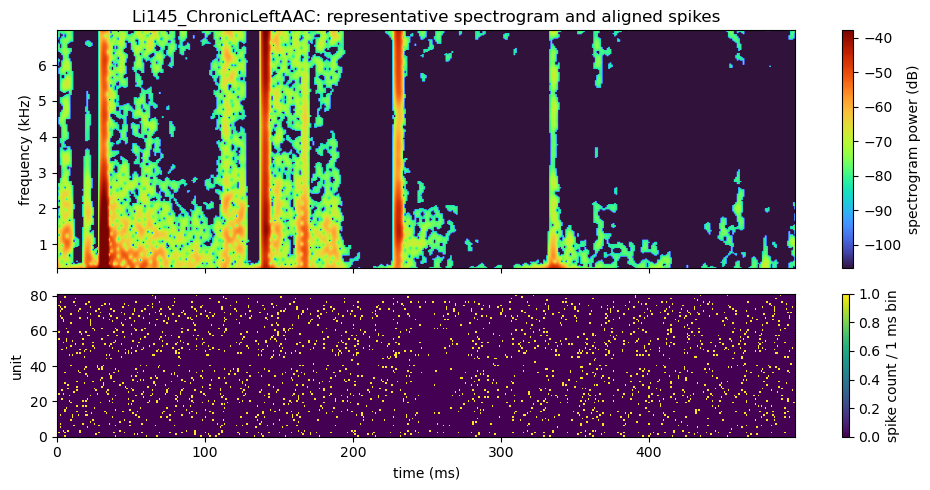

In [6]:
plot_representative_period("Li145_ChronicLeftAAC", duration_sec=0.5)

# 4. Audio event clustering
## 4.1 Event detection
based on spectrogram amplitude

In [7]:
def robust_zscore_spectrogram(S):
    med = np.median(S, axis=0, keepdims=True)
    mad = np.median(np.abs(S - med), axis=0, keepdims=True)
    return (S - med) / (1.4826 * mad + 1e-6)


def mask_to_events(mask):
    idx = np.flatnonzero(mask)
    if len(idx) == 0:
        return []

    events = []
    s = idx[0]
    prev = idx[0]

    for x in idx[1:]:
        if x == prev + 1:
            prev = x
        else:
            if (prev + 1 - s) * STFT_STEP_SEC * 1000 >= MIN_EVENT_MS:
                events.append((s, prev + 1))
            s = x
            prev = x

    if (prev + 1 - s) * STFT_STEP_SEC * 1000 >= MIN_EVENT_MS:
        events.append((s, prev + 1))

    return events


def detect_events_for_bird(bird):
    S = data[bird]["X_audio"]
    time = data[bird]["time"]

    Z = robust_zscore_spectrogram(S)
    B = Z > EVENT_Z_THRESHOLD

    close_frames = max(1, int(round(CLOSE_GAP_MS / 1000 / STFT_STEP_SEC)))
    B = binary_closing(B, structure=np.ones((close_frames, 1))).astype(bool)

    win = max(1, int(round(EVENT_ANALYSIS_MS / 1000 / STFT_STEP_SEC)))
    pixel_count = np.convolve(B.sum(axis=1), np.ones(win), mode="same")

    vocal_mask = pixel_count >= EVENT_MIN_PIXELS
    events = mask_to_events(vocal_mask)

    rows = []
    for event_id, (s, e) in enumerate(events):
        rows.append({
            "bird": bird,
            "event_id": event_id,
            "start_idx": int(s),
            "end_idx": int(e),
            "start_sec": float(time[s]),
            "end_sec": float(time[e - 1] + STFT_STEP_SEC),
            "duration_ms": float((e - s) * STFT_STEP_SEC * 1000),
            "score": float(pixel_count[s:e].max()),
        })

    return pd.DataFrame(rows)

In [8]:
events_df = pd.concat(
    [detect_events_for_bird(bird) for bird in BIRDS],
    ignore_index=True,
)

display(events_df.groupby("bird").size().reset_index(name="n_events"))
display(events_df["duration_ms"].describe())

,bird,n_events
0,Bl122_ChronicLeftAAC,2210
1,Li145_ChronicLeftAAC,1546
2,Or61_ChronicLeftAAC,722
3,Ti81_ChronicLeftAAC,193


count    4671.000000
mean       14.359666
std        24.590643
min         2.000000
25%         5.000000
50%         8.000000
75%        14.000000
max       390.000000
Name: duration_ms, dtype: float64

## 4.2 clustering
PCA + UMAP + DBSCAN

In [9]:
AUDIO_WINDOW_MS = int(
    np.ceil(max(MIN_AUDIO_WINDOW_MS, events_df["duration_ms"].max()) / 10) * 10
)
AUDIO_WINDOW_BINS = int(round(AUDIO_WINDOW_MS / 1000 / STFT_STEP_SEC))

n_truncated = int((events_df["duration_ms"] > AUDIO_WINDOW_MS).sum())

print("AUDIO_WINDOW_MS:", AUDIO_WINDOW_MS)
print("AUDIO_WINDOW_BINS:", AUDIO_WINDOW_BINS)
print("events truncated:", n_truncated)

AUDIO_WINDOW_MS: 390
AUDIO_WINDOW_BINS: 390
events truncated: 0


In [10]:
def pool_freq(S, pool=4):
    T, F = S.shape
    F2 = (F // pool) * pool
    return S[:, :F2].reshape(T, F2 // pool, pool).mean(axis=2)


def event_to_audio_image(S_event, fixed_len, freq_pool=4):
    S = pool_freq(S_event, pool=freq_pool)

    lo, hi = np.percentile(S, [1, 99.7])
    S = (S - lo) / (hi - lo + 1e-8)
    S = np.clip(S, 0, 1)

    S[S < 0.35] = 0.0

    out = np.zeros((fixed_len, S.shape[1]), dtype=np.float32)
    L = min(fixed_len, S.shape[0])
    out[:L] = S[:L]

    return out


def get_balanced_events(events_df):
    rows = []

    for bird in BIRDS:
        df = events_df[events_df["bird"] == bird].copy()

        if len(df) > MAX_EVENTS_PER_BIRD:
            df = df.sample(MAX_EVENTS_PER_BIRD, random_state=RANDOM_STATE)

        rows.append(df)

    return pd.concat(rows, ignore_index=True)


events_use = get_balanced_events(events_df)

X_audio_event = []

for _, row in tqdm(events_use.iterrows(), total=len(events_use), desc="audio features"):
    bird = row["bird"]
    s = int(row["start_idx"])
    e = int(row["end_idx"])

    S_event = data[bird]["X_audio"][s:e]
    A = event_to_audio_image(
        S_event,
        fixed_len=AUDIO_WINDOW_BINS,
        freq_pool=FREQ_POOL,
    )

    X_audio_event.append(A.ravel())

X_audio_event = np.vstack(X_audio_event)

print("audio event matrix:", X_audio_event.shape)
display(events_use.groupby("bird").size().reset_index(name="n_used"))

audio features:   0%|          | 0/1393 [00:00<?, ?it/s]

audio event matrix: (1393, 22230)


,bird,n_used
0,Bl122_ChronicLeftAAC,400
1,Li145_ChronicLeftAAC,400
2,Or61_ChronicLeftAAC,400
3,Ti81_ChronicLeftAAC,193


In [11]:
X_audio_z = StandardScaler().fit_transform(X_audio_event)

audio_pca = PCA(
    n_components=min(AUDIO_PCA_DIM, X_audio_z.shape[0] - 1, X_audio_z.shape[1]),
    random_state=RANDOM_STATE,
)

Z_audio = audio_pca.fit_transform(X_audio_z)

audio_umap = umap.UMAP(
    n_neighbors=AUDIO_UMAP_N_NEIGHBORS,
    min_dist=AUDIO_UMAP_MIN_DIST,
    metric="euclidean",
    random_state=RANDOM_STATE,
)

U_audio = audio_umap.fit_transform(Z_audio)

events_use = events_use.copy()
events_use["audio_umap1"] = U_audio[:, 0]
events_use["audio_umap2"] = U_audio[:, 1]

U_scaled = StandardScaler().fit_transform(U_audio)

db = DBSCAN(
    eps=DBSCAN_EPS,
    min_samples=DBSCAN_MIN_SAMPLES,
)

events_use["audio_cluster"] = db.fit_predict(U_scaled)

CLUSTERS = (
    events_use.loc[events_use["audio_cluster"] != -1, "audio_cluster"]
    .value_counts()
    .index
    .to_list()
)

print("audio PCA explained variance:")
print(np.round(audio_pca.explained_variance_ratio_[:10], 3))

print("\ncluster counts; -1 = DBSCAN noise")
display(events_use["audio_cluster"].value_counts().sort_index())

print("clusters used:", CLUSTERS)

/home/ganchao/miniconda3/envs/vfm/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


audio PCA explained variance:
[0.316 0.215 0.083 0.046 0.039 0.032 0.021 0.019 0.016 0.015]

cluster counts; -1 = DBSCAN noise


audio_cluster
0    1219
1      98
2      76
Name: count, dtype: int64

clusters used: [0, 1, 2]


/tmp/ipykernel_1029518/1974486302.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(CLUSTERS), 1))


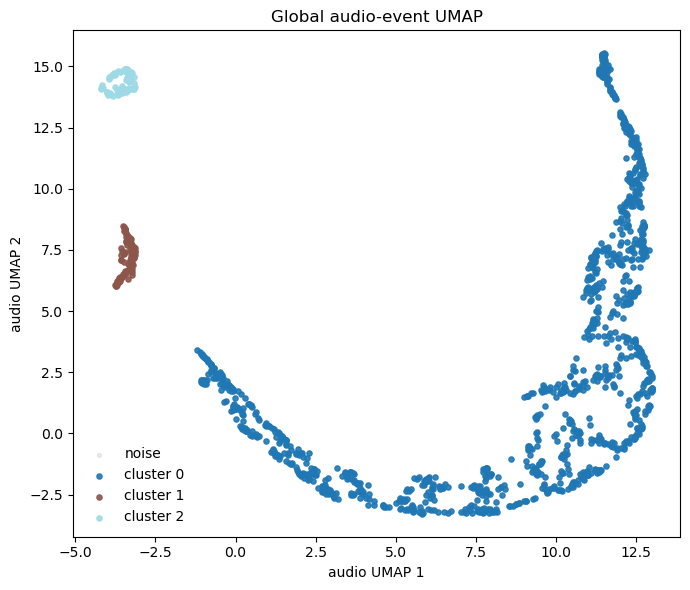

In [12]:
cmap = plt.cm.get_cmap("tab20", max(len(CLUSTERS), 1))
cluster_colors = {c: cmap(i) for i, c in enumerate(CLUSTERS)}

plt.figure(figsize=(7, 6))

noise = events_use["audio_cluster"] == -1

plt.scatter(
    events_use.loc[noise, "audio_umap1"],
    events_use.loc[noise, "audio_umap2"],
    s=8,
    color="lightgrey",
    alpha=0.45,
    label="noise",
)

for c in CLUSTERS:
    df = events_use[events_use["audio_cluster"] == c]
    plt.scatter(
        df["audio_umap1"],
        df["audio_umap2"],
        s=14,
        color=cluster_colors[c],
        alpha=0.9,
        label=f"cluster {c}",
    )

plt.xlabel("audio UMAP 1")
plt.ylabel("audio UMAP 2")
plt.title("Global audio-event UMAP")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# 5. neural latent traj for each cluster

In [14]:
#### see setting block

# # neural normalization
# # False: use smoothed firing rate in Hz
# # True:  use unit-wise z-scored smoothed firing rate
# NEURAL_UNIT_ZSCORE = False
# BASELINE_SUBTRACT = True

## 5.1 smoothing
z-scoring after PCA is optional

In [15]:
def smooth_spikes_to_rate(Y_counts):
    sigma_bins = SPIKE_SMOOTH_MS / 1000 / STFT_STEP_SEC

    R = gaussian_filter1d(
        Y_counts.astype(np.float32),
        sigma=sigma_bins,
        axis=0,
        mode="nearest",
    )

    return R / STFT_STEP_SEC


def build_neural_signal_by_bird():
    """
    Build neural signal used for PCA / heatmaps.

    If NEURAL_UNIT_ZSCORE = False:
        signal = smoothed firing rate in Hz

    If NEURAL_UNIT_ZSCORE = True:
        signal = unit-wise z-scored smoothed firing rate
    """
    out = {}

    for bird in BIRDS:
        R = smooth_spikes_to_rate(data[bird]["Y_spikes"])

        if NEURAL_UNIT_ZSCORE:
            mu = R.mean(axis=0, keepdims=True)
            sd = R.std(axis=0, keepdims=True) + 1e-8
            R = (R - mu) / sd

        out[bird] = R.astype(np.float32)

    return out


neural_signal_by_bird = build_neural_signal_by_bird()

print("NEURAL_UNIT_ZSCORE:", NEURAL_UNIT_ZSCORE)
print("neural signal:", NEURAL_SIGNAL_LABEL)

NEURAL_UNIT_ZSCORE: False
neural signal: smoothed firing rate (Hz)


In [16]:
def extract_neural_windows(events_use):
    pre = int(round(TRAJ_PRE_MS / 1000 / STFT_STEP_SEC))
    post = int(round(TRAJ_POST_MS / 1000 / STFT_STEP_SEC))

    rows = []
    windows = []

    df = events_use[events_use["audio_cluster"].isin(CLUSTERS)].copy()

    for _, row in df.iterrows():
        bird = row["bird"]
        s = int(row["start_idx"])

        i0 = s - pre
        i1 = s + post

        Y = neural_signal_by_bird[bird]

        if i0 < 0 or i1 > len(Y):
            continue

        W = Y[i0:i1].copy()

        if BASELINE_SUBTRACT and pre > 0:
            W = W - W[:pre].mean(axis=0, keepdims=True)

        rows.append(row)
        windows.append(W.astype(np.float32))

    valid_events = pd.DataFrame(rows).reset_index(drop=True)
    valid_events["neural_id"] = np.arange(len(valid_events))

    rel_time_ms = np.arange(-pre, post) * STFT_STEP_SEC * 1000

    return valid_events, windows, rel_time_ms


valid_events, neural_windows, rel_time_ms = extract_neural_windows(events_use)

print("valid neural windows:", len(valid_events))
print("baseline subtract:", BASELINE_SUBTRACT)
print("neural windows:", HEATMAP_LABEL)

display(valid_events.groupby(["bird", "audio_cluster"]).size().reset_index(name="n"))

valid neural windows: 1389
baseline subtract: True
neural windows: baseline-subtracted firing rate (Hz)


,bird,audio_cluster,n
0,Bl122_ChronicLeftAAC,0,360
1,Bl122_ChronicLeftAAC,1,24
2,Bl122_ChronicLeftAAC,2,15
3,Li145_ChronicLeftAAC,0,332
4,Li145_ChronicLeftAAC,1,37
5,Li145_ChronicLeftAAC,2,30
6,Or61_ChronicLeftAAC,0,363
7,Or61_ChronicLeftAAC,1,20
8,Or61_ChronicLeftAAC,2,15
9,Ti81_ChronicLeftAAC,0,161


## 5.2 PCA

In [17]:
def fit_within_bird_pca(valid_events, neural_windows):
    Z_windows = [None] * len(neural_windows)
    pca_by_bird = {}

    for bird in BIRDS:
        idx = valid_events.index[valid_events["bird"] == bird].to_numpy()

        if len(idx) == 0:
            continue

        X = np.concatenate([neural_windows[i] for i in idx], axis=0)

        pca = PCA(n_components=N_PC, random_state=RANDOM_STATE)
        pca.fit(X)

        for i in idx:
            Z_windows[i] = pca.transform(neural_windows[i])

        pca_by_bird[bird] = pca

        print(bird, "EVR:", np.round(pca.explained_variance_ratio_, 3))

    return Z_windows, pca_by_bird


Z_windows, pca_by_bird = fit_within_bird_pca(valid_events, neural_windows)

Bl122_ChronicLeftAAC EVR: [0.245 0.07  0.056]
Li145_ChronicLeftAAC EVR: [0.047 0.029 0.026]
Or61_ChronicLeftAAC EVR: [0.28  0.096 0.086]
Ti81_ChronicLeftAAC EVR: [0.197 0.071 0.049]


## 5.3 Figures

In [18]:
def pad_lim(lim, frac=0.05):
    lo, hi = lim
    pad = frac * (hi - lo + 1e-8)
    return lo - pad, hi + pad


audio_xlim = pad_lim((events_use["audio_umap1"].min(), events_use["audio_umap1"].max()))
audio_ylim = pad_lim((events_use["audio_umap2"].min(), events_use["audio_umap2"].max()))


def get_pc_lims_for_bird(bird):
    pc_lims = []

    for pc in range(N_PC):
        vals = []

        for c in CLUSTERS:
            df = valid_events[
                (valid_events["bird"] == bird) &
                (valid_events["audio_cluster"] == c)
            ]

            if len(df) < MIN_EVENTS_PER_CLUSTER_BIRD:
                continue

            Zs = [Z_windows[int(i)] for i in df["neural_id"]]
            vals.append(np.stack(Zs).mean(axis=0)[:, pc])

        if len(vals) == 0:
            pc_lims.append((-1, 1))
        else:
            v = np.concatenate(vals)
            pc_lims.append(pad_lim((v.min(), v.max()), frac=0.25))

    return pc_lims

### 5.3.1 Figure 2: per bird UMAP + neural PC trajectories

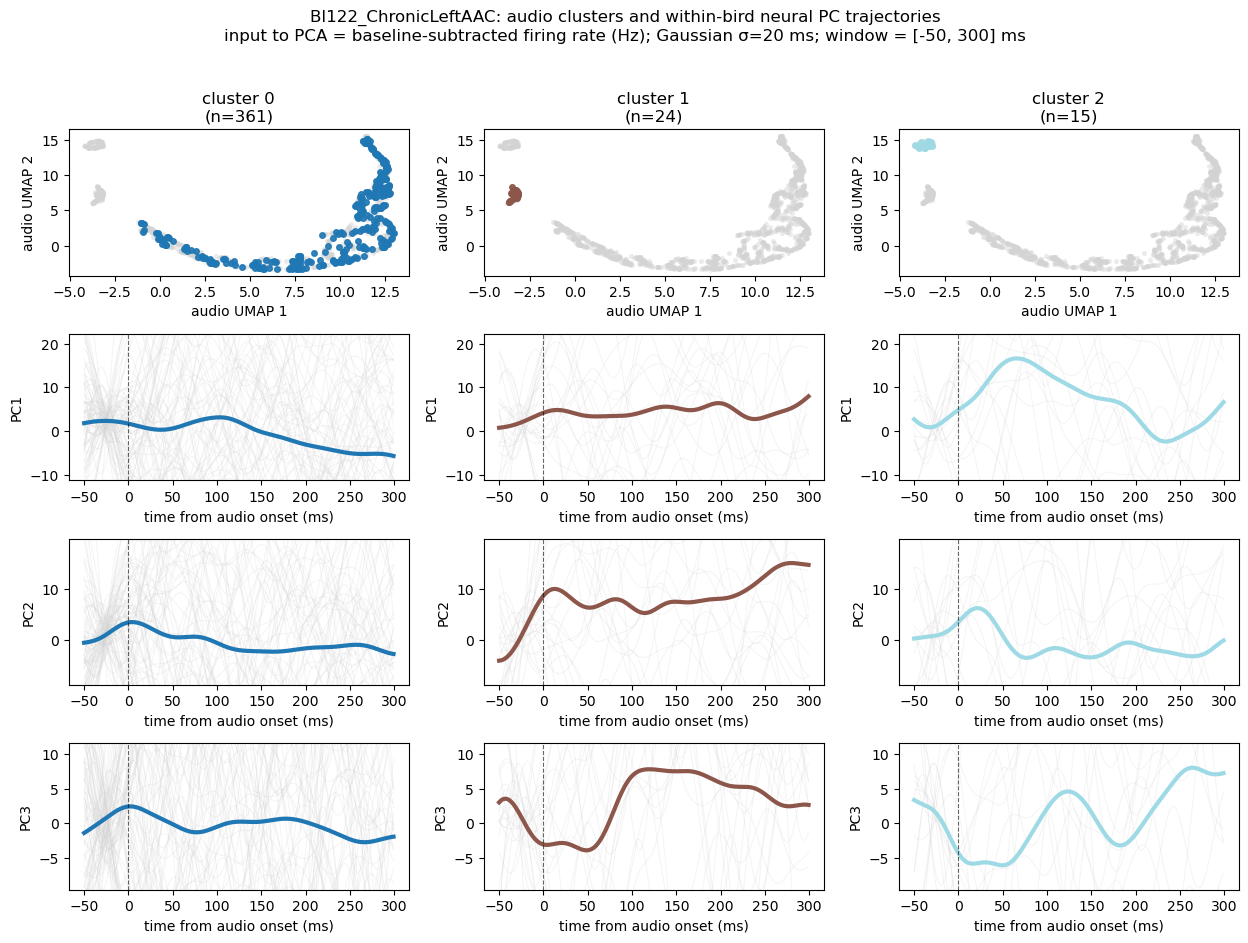

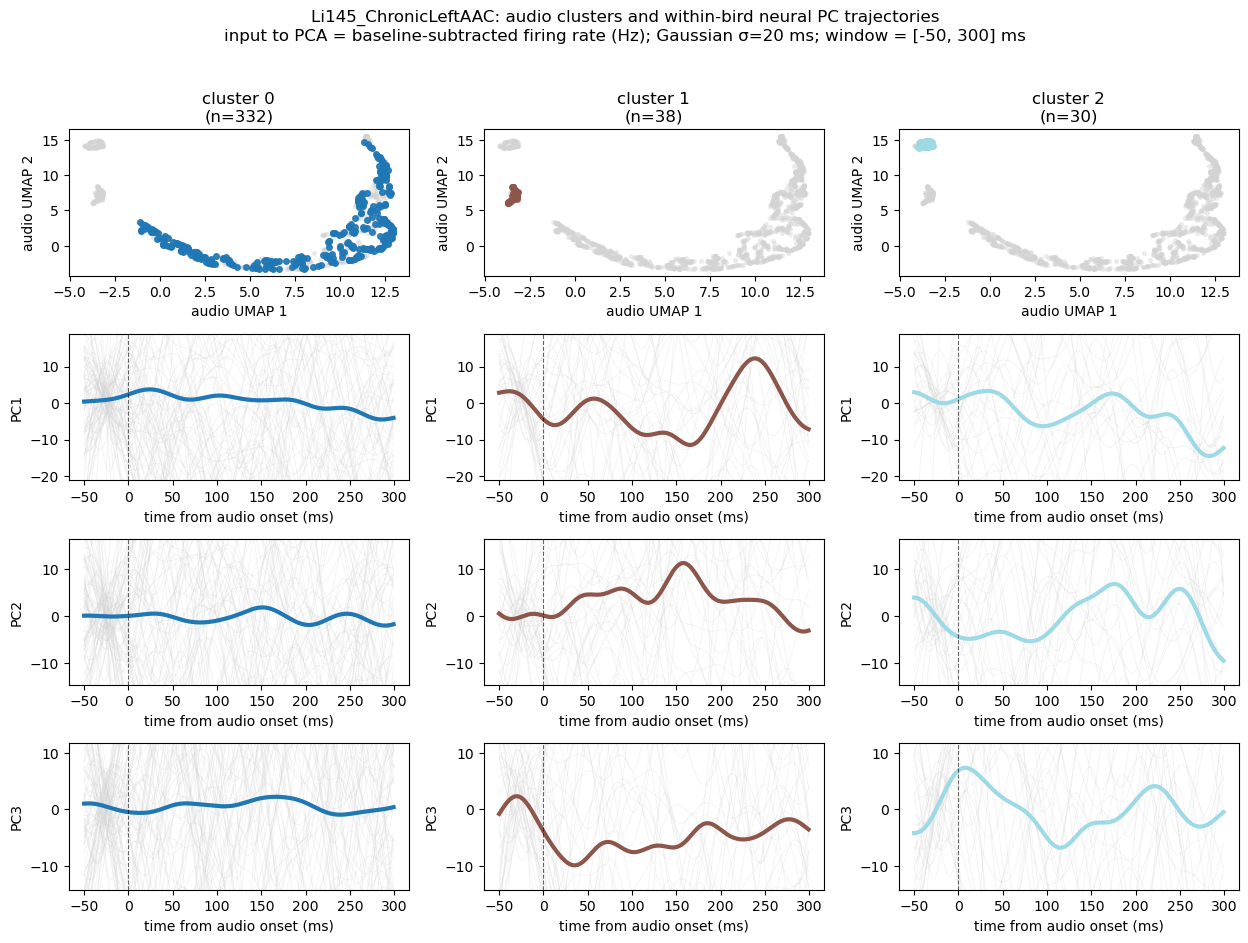

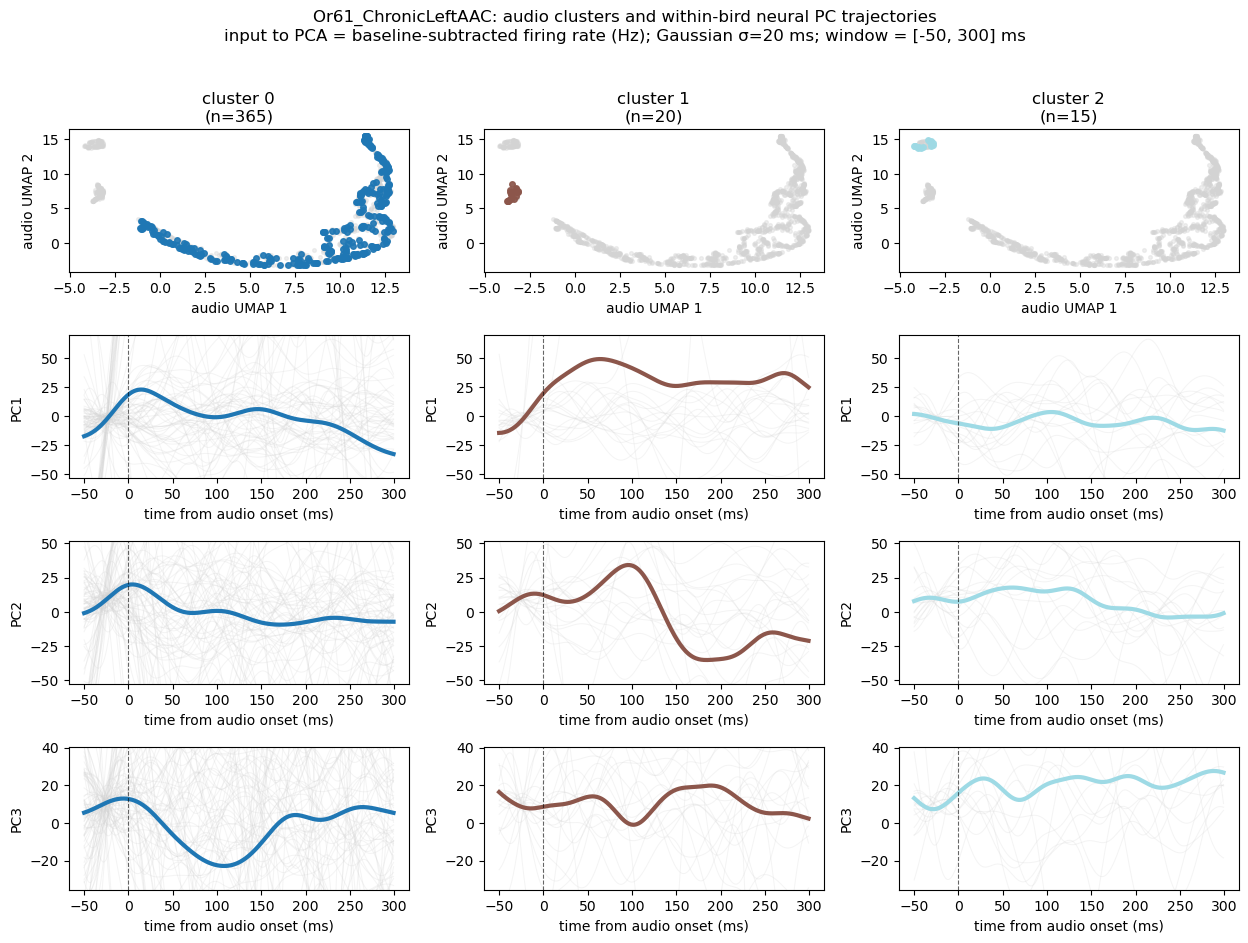

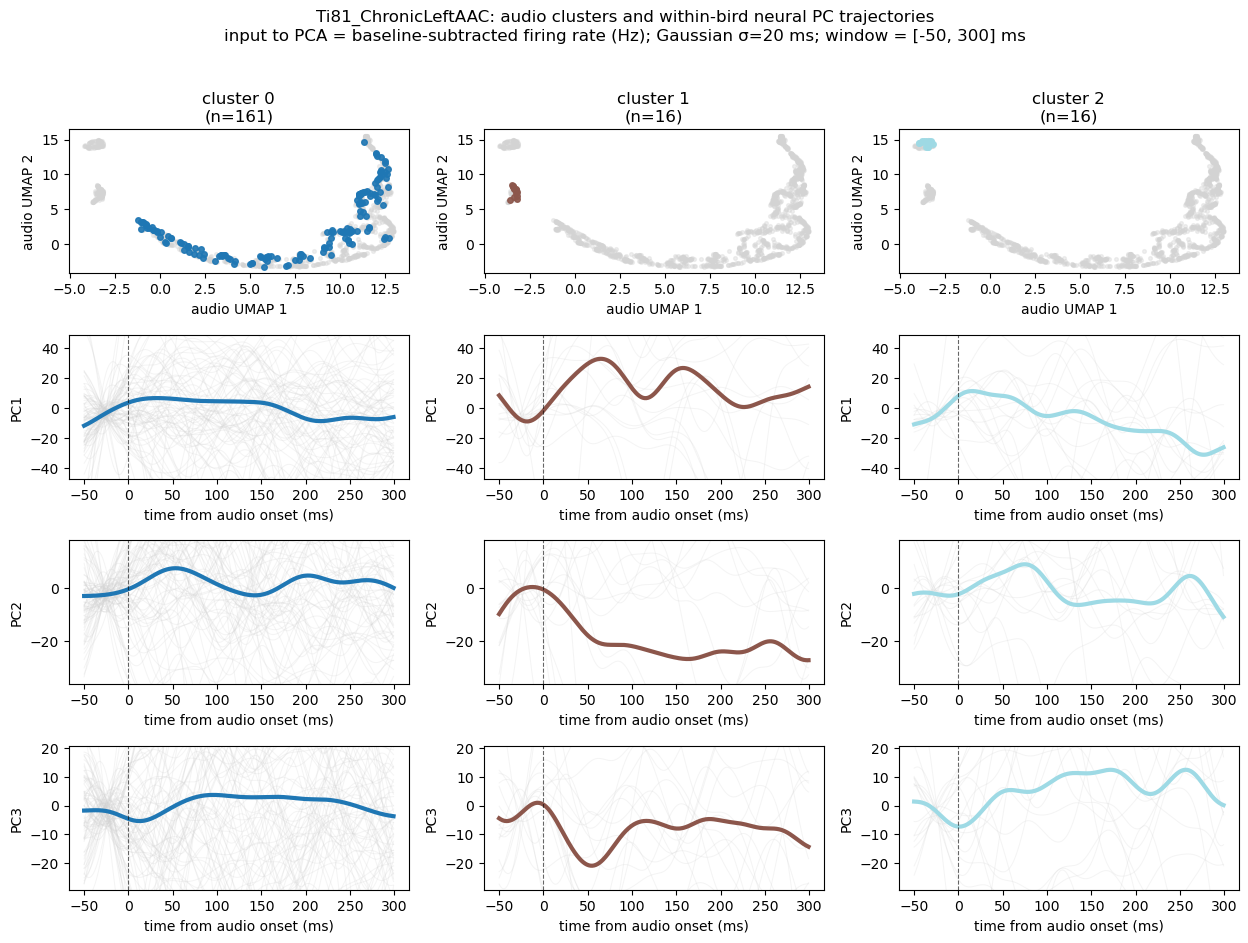

In [19]:
def plot_bird_umap_and_pc_trajectories(bird):
    K = len(CLUSTERS)
    pc_lims = get_pc_lims_for_bird(bird)

    fig, axes = plt.subplots(
        1 + N_PC,
        K,
        figsize=(4.2 * K, 2.3 * (1 + N_PC)),
        sharex=False,
        sharey=False,
    )

    if K == 1:
        axes = axes.reshape(1 + N_PC, 1)

    rng = np.random.default_rng(RANDOM_STATE)

    for col, c in enumerate(CLUSTERS):
        color = cluster_colors[c]

        ax = axes[0, col]

        ax.scatter(
            events_use["audio_umap1"],
            events_use["audio_umap2"],
            s=7,
            color="lightgrey",
            alpha=0.35,
        )

        df_audio = events_use[
            (events_use["bird"] == bird) &
            (events_use["audio_cluster"] == c)
        ]

        ax.scatter(
            df_audio["audio_umap1"],
            df_audio["audio_umap2"],
            s=16,
            color=color,
            alpha=0.9,
        )

        ax.set_xlim(*audio_xlim)
        ax.set_ylim(*audio_ylim)
        ax.set_title(f"cluster {c}\n(n={len(df_audio)})")
        ax.set_xlabel("audio UMAP 1")
        ax.set_ylabel("audio UMAP 2")

        df_neural = valid_events[
            (valid_events["bird"] == bird) &
            (valid_events["audio_cluster"] == c)
        ]

        if len(df_neural) < MIN_EVENTS_PER_CLUSTER_BIRD:
            for pc in range(N_PC):
                axes[1 + pc, col].axis("off")
            continue

        Zs = [Z_windows[int(i)] for i in df_neural["neural_id"]]

        if len(Zs) > MAX_TRAJ_PLOT:
            keep = rng.choice(len(Zs), MAX_TRAJ_PLOT, replace=False)
            Z_show = [Zs[i] for i in keep]
        else:
            Z_show = Zs

        Z_mean = np.stack(Zs).mean(axis=0)

        for pc in range(N_PC):
            ax = axes[1 + pc, col]

            for Z in Z_show:
                ax.plot(
                    rel_time_ms,
                    Z[:, pc],
                    color="lightgrey",
                    alpha=0.25,
                    linewidth=0.7,
                )

            ax.plot(
                rel_time_ms,
                Z_mean[:, pc],
                color=color,
                linewidth=3,
            )

            ax.axvline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
            ax.set_ylim(*pc_lims[pc])
            ax.set_ylabel(f"PC{pc + 1}")
            ax.set_xlabel("time from audio onset (ms)")

    fig.suptitle(
        f"{bird}: audio clusters and within-bird neural PC trajectories\n"
        f"input to PCA = {HEATMAP_LABEL}; "
        f"Gaussian σ={SPIKE_SMOOTH_MS} ms; "
        f"window = [-{TRAJ_PRE_MS}, {TRAJ_POST_MS}] ms",
        y=1.02,
    )

    plt.tight_layout()
    plt.show()


for bird in BIRDS:
    plot_bird_umap_and_pc_trajectories(bird)

### 5.3.2 Figure 3: representative spectrogram + spikes

In [20]:
def bird_short_name(bird):
    return bird.split("_")[0]


BIRD_COLORS = {
    bird: plt.cm.tab10(i)
    for i, bird in enumerate(BIRDS)
}

BIRD_MARKERS = {
    BIRDS[0]: "o",
    BIRDS[1]: "s",
    BIRDS[2]: "^",
    BIRDS[3]: "D",
}


def representative_event_for_bird_cluster(bird, c):
    """
    Pick one event for a given bird and audio cluster.

    Representative = closest to the global cluster centroid in UMAP space,
    but restricted to this bird.
    """
    df = valid_events[
        (valid_events["bird"] == bird) &
        (valid_events["audio_cluster"] == c)
    ].copy()

    if len(df) == 0:
        return None

    df_cluster = valid_events[valid_events["audio_cluster"] == c]

    center = df_cluster[["audio_umap1", "audio_umap2"]].mean().to_numpy()
    U = df[["audio_umap1", "audio_umap2"]].to_numpy()

    j = np.argmin(np.sum((U - center) ** 2, axis=1))
    return df.iloc[j]


def build_representative_table():
    rows = []

    for c in CLUSTERS:
        for bird in BIRDS:
            row = representative_event_for_bird_cluster(bird, c)
            if row is not None:
                rows.append(row)

    return pd.DataFrame(rows).reset_index(drop=True)


rep_events = build_representative_table()

display(
    rep_events[["bird", "audio_cluster", "event_id", "duration_ms", "audio_umap1", "audio_umap2"]]
)


def plot_umap_representatives(ax, c):
    """
    UMAP panel for one cluster.
    Grey = all events.
    Light color = all events in this cluster.
    Large markers = representative events, one per bird.
    """
    ax.scatter(
        events_use["audio_umap1"],
        events_use["audio_umap2"],
        s=6,
        color="lightgrey",
        alpha=0.35,
    )

    df_c = events_use[events_use["audio_cluster"] == c]
    ax.scatter(
        df_c["audio_umap1"],
        df_c["audio_umap2"],
        s=10,
        color=cluster_colors[c],
        alpha=0.25,
    )

    for bird in BIRDS:
        row = representative_event_for_bird_cluster(bird, c)
        if row is None:
            continue

        ax.scatter(
            row["audio_umap1"],
            row["audio_umap2"],
            s=80,
            color=BIRD_COLORS[bird],
            marker=BIRD_MARKERS[bird],
            edgecolor="black",
            linewidth=0.8,
            label=bird_short_name(bird),
        )

    ax.set_xlim(*audio_xlim)
    ax.set_ylim(*audio_ylim)
    ax.set_title(f"cluster {c}: representative points")
    ax.set_xlabel("audio UMAP 1")
    ax.set_ylabel("audio UMAP 2")


def plot_event_spectrogram(ax, row):
    bird = row["bird"]
    s = int(row["start_idx"])
    e = int(row["end_idx"])

    S = data[bird]["X_audio"][s:e]
    f = data[bird]["freq"]

    dur_ms = (e - s) * STFT_STEP_SEC * 1000
    S_show, vmin, vmax = display_spectrogram(S)

    ax.imshow(
        S_show.T,
        origin="lower",
        aspect="auto",
        cmap="turbo",
        vmin=vmin,
        vmax=vmax,
        extent=[0, dur_ms, f[0] / 1000, f[-1] / 1000],
    )

    ax.set_ylabel("freq\n(kHz)")
    ax.set_xlabel("time (ms)")
    ax.set_title(
        f"{bird_short_name(bird)} spectrogram\n"
        f"event {int(row['event_id'])}, {dur_ms:.0f} ms"
    )


def build_unit_orders():
    """
    Fixed unit order per bird, so heatmaps are comparable across clusters.
    Units are sorted by peak time in the bird-average response.
    """
    orders = {}

    for bird in BIRDS:
        df = valid_events[valid_events["bird"] == bird]

        if len(df) == 0:
            orders[bird] = None
            continue

        H = np.stack([
            neural_windows[int(i)].T
            for i in df["neural_id"]
        ]).mean(axis=0)

        orders[bird] = np.argsort(np.argmax(H, axis=1))

    return orders


unit_orders = build_unit_orders()


def representative_neural_heatmap(row):
    """
    Neural heatmap from the same event as the representative spectrogram.
    Output: units x time.
    """
    bird = row["bird"]
    neural_id = int(row["neural_id"])

    H = neural_windows[neural_id].T

    if unit_orders[bird] is not None:
        H = H[unit_orders[bird]]

    return H


def compute_representative_heatmap_vabs():
    vals = []

    for _, row in rep_events.iterrows():
        H = representative_neural_heatmap(row)
        vals.append(H.ravel())

    vals = np.concatenate(vals)
    return np.percentile(np.abs(vals), 99)


HEATMAP_VABS_REP = compute_representative_heatmap_vabs()
print("HEATMAP_VABS_REP:", HEATMAP_VABS_REP)

,bird,audio_cluster,event_id,duration_ms,audio_umap1,audio_umap2
0,Bl122_ChronicLeftAAC,0,762,10.0,9.002576,1.491718
1,Li145_ChronicLeftAAC,0,55,12.0,9.633805,1.882095
2,Or61_ChronicLeftAAC,0,278,17.0,9.208856,1.632731
3,Ti81_ChronicLeftAAC,0,128,15.0,9.582286,1.966699
4,Bl122_ChronicLeftAAC,1,314,3.0,-3.468054,7.345493
5,Li145_ChronicLeftAAC,1,1430,3.0,-3.273387,7.212131
6,Or61_ChronicLeftAAC,1,654,3.0,-3.559630,7.106851
7,Ti81_ChronicLeftAAC,1,91,3.0,-3.264116,7.333744
8,Bl122_ChronicLeftAAC,2,1974,2.0,-3.545153,14.206949
9,Li145_ChronicLeftAAC,2,1072,2.0,-3.414839,14.448616


HEATMAP_VABS_REP: 148.85699859619146


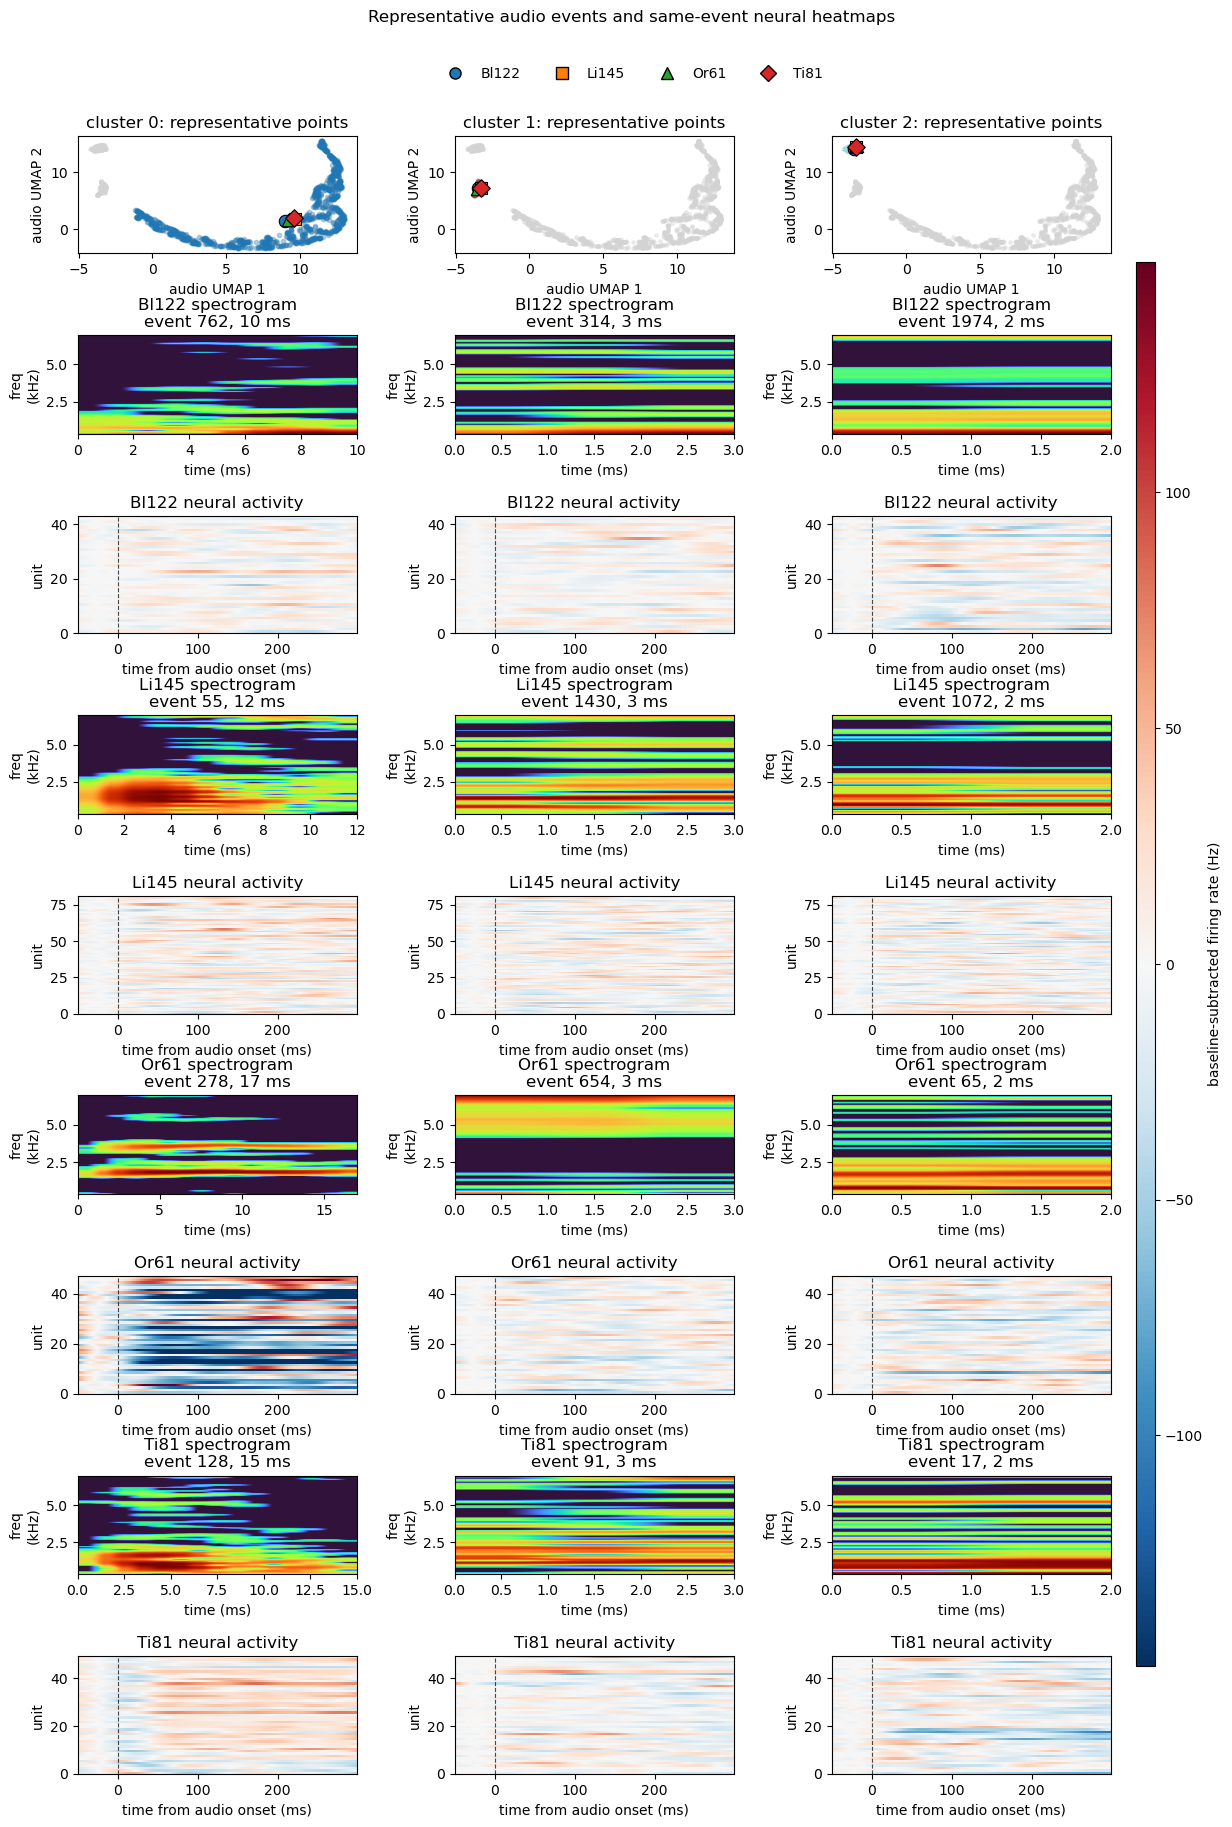

In [21]:
def plot_representative_spectrograms_and_neural_heatmaps():
    K = len(CLUSTERS)
    n_rows = 1 + 2 * len(BIRDS)

    height_ratios = [1.25]
    for _ in BIRDS:
        height_ratios += [1.05, 1.25]

    fig, axes = plt.subplots(
        n_rows,
        K,
        figsize=(4.2 * K, 2.0 * n_rows),
        gridspec_kw={"height_ratios": height_ratios},
        sharex=False,
        sharey=False,
        constrained_layout=False,
    )

    if K == 1:
        axes = axes.reshape(n_rows, 1)

    last_im = None

    for col, c in enumerate(CLUSTERS):
        plot_umap_representatives(axes[0, col], c)

        for b_idx, bird in enumerate(BIRDS):
            spec_row = 1 + 2 * b_idx
            heat_row = spec_row + 1

            row = representative_event_for_bird_cluster(bird, c)

            if row is None:
                axes[spec_row, col].axis("off")
                axes[heat_row, col].axis("off")
                axes[spec_row, col].set_title(f"{bird_short_name(bird)}: no event")
                continue

            plot_event_spectrogram(axes[spec_row, col], row)

            H = representative_neural_heatmap(row)

            last_im = axes[heat_row, col].imshow(
                H,
                origin="lower",
                aspect="auto",
                interpolation="nearest",
                cmap="RdBu_r",
                vmin=-HEATMAP_VABS_REP,
                vmax=HEATMAP_VABS_REP,
                extent=[rel_time_ms[0], rel_time_ms[-1], 0, H.shape[0]],
            )

            axes[heat_row, col].axvline(
                0,
                color="black",
                linestyle="--",
                linewidth=0.8,
                alpha=0.7,
            )

            axes[heat_row, col].set_ylabel("unit")
            axes[heat_row, col].set_xlabel("time from audio onset (ms)")
            axes[heat_row, col].set_title(f"{bird_short_name(bird)} neural activity")

    handles = []
    labels = []

    for bird in BIRDS:
        h = plt.Line2D(
            [0], [0],
            marker=BIRD_MARKERS[bird],
            color="w",
            markerfacecolor=BIRD_COLORS[bird],
            markeredgecolor="black",
            markersize=8,
            linewidth=0,
        )
        handles.append(h)
        labels.append(bird_short_name(bird))

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=len(BIRDS),
        frameon=False,
        bbox_to_anchor=(0.5, 0.995),
    )

    fig.subplots_adjust(
        left=0.06,
        right=0.88,
        bottom=0.04,
        top=0.95,
        wspace=0.35,
        hspace=0.75,
    )

    if last_im is not None:
        cax = fig.add_axes([0.90, 0.10, 0.015, 0.78])
        fig.colorbar(
            last_im,
            cax=cax,
            label=HEATMAP_LABEL,
        )

    fig.suptitle(
        "Representative audio events and same-event neural heatmaps",
        y=1.02,
    )

    plt.show()


plot_representative_spectrograms_and_neural_heatmaps()